# Advanced Agentic Retrieval: Orchestrating Multi-Source RAG with LangGraph

This notebook dives deep into advanced Retrieval-Augmented Generation (RAG) by moving beyond simple single-step retrieval and implementing a sophisticated, multi-agent workflow using LangGraph. In real-world applications, answering a query often requires more than just searching one document or one database; it might require consulting internal technical reports *and* checking current web events. Simple RAG pipelines fail when the source of truth is ambiguous or distributed across multiple modalities (e.g., PDF documents and live news feeds).

We solve this by building an **agentic decision layer**. This agent acts as a router, intelligently deciding whether the incoming query requires internal document knowledge, real-time web search, general knowledge, or if it can be answered immediately. By defining specialized tools (`vector_store_search` for local documents and `web_search` for current events) and integrating them into a LangGraph state machine, we create an autonomous system that plans its steps, executes the necessary retrievals, aggregates the context, and finally generates a comprehensive answer.

By mastering this pattern, you learn how to build robust, enterprise-grade RAG systems that are not only accurate but also highly adaptable. You will understand the critical role of state management in complex workflows and how to use structured output (Pydantic) within LLMs to enforce reliable decision-making, transforming a simple chatbot into a powerful, multi-source research assistant.

### Learning Objectives

Upon completing this notebook, you will be able to:

*   **Implement Multi-Source Retrieval:** Define and utilize multiple specialized tools (e.g., local vector store search, web API calls) within a single RAG pipeline.
*   **Master Agentic Routing:** Build an LLM-powered router that analyzes a query and makes a structured decision about which retrieval tool(s) are necessary before proceeding.
*   **Understand LangGraph State Management:** Define and manage complex application state (`AgenticRAGState`) to track intermediate results, context accumulation, and the number of retrieval attempts across multiple graph steps.
*   **Build Multi-Step Workflows:** Construct a sophisticated LangGraph workflow that orchestrates sequential decision-making (Route $\rightarrow$ Tool Use $\rightarrow$ Generation) rather than executing a single linear chain.
*   **Enhance RAG Robustness:** Design systems that can handle ambiguity and uncertainty by explicitly managing retrieval steps and context aggregation, leading to more reliable and grounded answers.


### Setup and Imports

This cell imports all necessary libraries, classes, and functions for building an advanced RAG system using LangGraph. It initializes environment variables (like API keys) and brings in components for tool use (`@tool`), message handling, prompt templating, document loading/splitting, embedding/vector storage (Chroma), OpenAI models, and the core graph structure from `langgraph`.


In [1]:
import os
import operator
from typing import Annotated, Literal
from pydantic import BaseModel
from tavily import TavilyClient
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
load_dotenv()


True

### Document Loading

This cell initializes a `PyPDFLoader` to load documents from a specified PDF file path. The loader reads the document and converts it into a list of LangChain `Document` objects, which are stored in `raw_docs`. This step is crucial for preparing unstructured data for subsequent embedding and retrieval processes.


In [2]:
loader = PyPDFLoader("../documents/evs_oil_price_shock.pdf") # Initialize the loader with the path to the PDF document
raw_docs = loader.load() # Load the document, which returns a list of Document objects (one per page)

print(f"Loaded {len(raw_docs)} pages") # Print the total number of documents/pages loaded


Loaded 15 pages


### Chunking Documents for Retrieval

This cell uses `RecursiveCharacterTextSplitter` to break down large documents (`raw_docs`) into smaller, manageable chunks. This process is crucial because embedding models have token limits and smaller chunks generally lead to more precise retrieval when using vector databases.


In [3]:
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")


Split into 51 chunks


### Embedding Model Initialization

This line initializes the embedding model used to convert text into numerical vectors. The `OpenAIEmbeddings` class handles the connection and API calls necessary to generate high-quality embeddings using OpenAI's specified model (`text-embedding-3-small`).


In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")


### Vector Store Initialization and Population

This cell initializes an in-memory Chroma vector store (`vectorstore`) using the specified embedding function. It then populates this store by adding a list of pre-chunked documents (`chunks`), making them available for retrieval during subsequent RAG steps.


In [ ]:
# in-memory only; re-running this cell re-embeds from scratch
vectorstore = Chroma(
    collection_name="rag_eval_retry",
    embedding_function=embeddings,
)

# Add the list of pre-chunked documents (chunks) to the vector store
vectorstore.add_documents(documents=chunks)

print("Vector store ready")


### LLM Initialization

This cell initializes two instances of the `ChatOpenAI` model. One instance (`llm`) is designated for routing and general generation tasks, while a second instance (`agent_llm`) is specifically set up to act as the core reasoning agent node within the LangGraph structure.


In [6]:
llm = ChatOpenAI(model="gpt-5-mini")        # Used for initial question routing and final content generation

agent_llm = ChatOpenAI(model="gpt-5-mini")  # Dedicated LLM instance for the agent node logic; tools will be bound to it later


### State Definition for Agentic RAG

This class defines the comprehensive state object (`AgenticRAGState`) used within a LangGraph workflow. It inherits from `MessagesState` and explicitly tracks all necessary components—including the initial query, retrieved documents, accumulated context, generation output, and crucial control variables like `retrieval_count` and `max_retrieval_steps`—to manage multi-step, tool-using retrieval processes.


In [7]:
class AgenticRAGState(MessagesState):

    query: str
    retrieved_docs: Annotated[list[Document], operator.add]
    context: Annotated[str, operator.add]
    generation: str
    needs_retrieval: bool
    retrieval_count: int       # incremented after each tool-call round
    max_retrieval_steps: int   # cap on tool-call rounds before forcing generate


### Step explanation

This cell defines a Pydantic model, `RouteDecision`, which serves as the structured output schema for an LLM call. It dictates that the calling function must return a boolean value (`needs_retrieval`) indicating whether external document retrieval is necessary to answer the user's query.


In [8]:
class RouteDecision(BaseModel):

    # This field determines if the LLM believes external knowledge (retrieval) is needed.
    needs_retrieval: bool


### Tool Definition: Vector Store Search

This function defines a callable tool (`vector_store_search`) that interfaces with the underlying vector database. It takes a `query` and an integer `k` (number of results) to retrieve relevant document passages, which are then formatted into a context string and returned alongside the original documents.


In [9]:
@tool(response_format="content_and_artifact")
def vector_store_search(query: str, k: int = 3):
    """Search the vector store for relevant document passages.
    Adjust k (default 3) to retrieve more or fewer passages."""
    
    docs = vectorstore.similarity_search(query, k=k)
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in docs)
    
    return context, docs

### Tool Definition: Web Search

This function defines a callable tool, `web_search`, that interfaces with the Tavily API to retrieve real-time information from the web. It is crucial for RAG systems when the knowledge base might be outdated or requires current events, ensuring the LLM has access to up-to-date context.


In [10]:
@tool(response_format="content_and_artifact")
def web_search(query: str, max_results: int = 3):
    """Search the web for current or real-time information.
    Adjust max_results (default 3) to control how many results are returned."""
    
    client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    response = client.search(query, max_results=max_results)
    
    docs = [
        Document(
            page_content=r["content"],
            metadata={"source": r["url"], "title": r.get("title", "")},
        )
        for r in response["results"]
    ]
    content = "\n\n## Web Search Results\n\n" + "\n\n".join(d.page_content for d in docs)
    return content, docs

### Tool Definition and Agent Setup

This cell defines the set of available tools (`vector_store_search`, `web_search`) and equips the main agent LLM with knowledge of these tools using `.bind_tools()`. It then initializes a dedicated `ToolNode` to manage the execution flow when the agent decides it needs to use one or more external tools.


In [11]:
tools = [vector_store_search, web_search] # Define the list of available tools (e.g., vector database search and general web search).

agent_llm_with_tools = agent_llm.bind_tools(tools) # Bind the defined tools to the main LLM instance, allowing the model to generate calls for these functions.

tool_node = ToolNode(tools) # Initialize a dedicated node responsible for executing the tool calls generated by the agent.


### Router Node (Question Classification)

This function acts as a router node in the LangGraph workflow. It uses an LLM to classify whether the incoming user query requires external retrieval (from specialized documents or the web) or if it can be answered using general knowledge, ensuring efficient resource use.


In [12]:
# route_question node — classifies whether the query needs retrieval
def route_question(state: AgenticRAGState) -> dict:

    # Define the prompt template for classification
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Classify whether the following question requires retrieving information from a specialized document or the web, or can be answered from your own general knowledge."),
        ("human", "{query}"),
    ])

    # Create a chain that uses the LLM and forces structured output (RouteDecision)
    chain = prompt_template | llm.with_structured_output(RouteDecision)
    
    # Invoke the chain using the query from the state, getting a structured decision object
    decision = chain.invoke({"query": state["query"]})

    # Return the classification result to guide the graph's flow
    return {"needs_retrieval": decision.needs_retrieval}


In [13]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools."
)

# agent node — decides which tool(s) to call based on the query
def agent(state: AgenticRAGState) -> dict:

    messages = state["messages"]
    if not messages:
        messages = [SystemMessage(content=AGENT_SYSTEM_PROMPT),
                    HumanMessage(content=state["query"])]

    response = agent_llm_with_tools.invoke(messages)

    return {"messages": [response]}

### Node Function Explanation (Tool Output Processing)

This function processes the `ToolMessage` objects within the agent's state. It extracts all content from these messages to form a consolidated context string and aggregates any associated artifacts (`msg.artifact`) into a list of retrieved documents, making them available for subsequent steps in the graph.


In [14]:
# collect_tool_output node — drains ToolMessages into state fields
def collect_tool_output(state: AgenticRAGState) -> dict:

    # Filter the 'messages' history to only include messages generated by tools (ToolMessage)
    tool_messages = [m for m in state["messages"] if isinstance(m, ToolMessage)]
    all_docs, context_parts = [], []

    # Iterate through all identified tool output messages
    for msg in tool_messages:
        # Collect the textual content from the tool message into a list of parts
        context_parts.append(msg.content)
        # Extend the list of documents with any artifacts attached to the message
        all_docs.extend(msg.artifact)

    # Return a dictionary containing the consolidated context string and the list of retrieved documents
    return {
        "context": "\n\n".join(context_parts),
        "retrieved_docs": all_docs,
    }


### Node Function: Generating the Final Answer

This function acts as a final node in the LangGraph workflow. It takes the current state (which includes the original query and any retrieved context) and generates the final answer using an LLM. Crucially, it dynamically adjusts its prompt: if context is available, it forces the LLM to use *only* that context; otherwise, it relies on general knowledge.


In [15]:
# generate node — produces the final answer with or without retrieved context
def generate(state: AgenticRAGState) -> dict:

    # Extract the original query and the potentially retrieved context from the state.
    query = state["query"]
    context = state.get("context") or ""

    # Check if any context was successfully retrieved during the graph execution.
    if context:
        # If context exists, set up a prompt that strictly instructs the LLM to use only this context.
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
            ("human", "{query}"),
        ])
        # Invoke the LLM with both the specific context and the user query.
        response = (prompt_template | llm).invoke({"context": context, "query": query})

    else:
        # If no context was retrieved, set up a general knowledge prompt.
        prompt_template = ChatPromptTemplate.from_messages([
            ("system", "Answer the following question from your general knowledge."),
            ("human", "{query}"),
        ])
        # Invoke the LLM using only the user query, relying on its internal knowledge base.
        response = (prompt_template | llm).invoke({"query": query})

    # Return a dictionary containing the generated answer content to update the graph state.
    return {"generation": response.content}


### Node Function Explanation

This function, `check_retrieval_limit`, acts as a state-updating node in the LangGraph workflow. It increments a counter (`retrieval_count`) stored within the agent's state, which is crucial for implementing resource limits or controlling the number of retrieval steps allowed during the RAG process.


In [17]:
# check_retrieval_limit node — increments the retrieval counter after each tool round
# This function takes the current state (AgenticRAGState) and returns a dictionary update.
def check_retrieval_limit(state: AgenticRAGState) -> dict:
    # Retrieve the current count, defaulting to 0 if not present in the state.
    count = state.get("retrieval_count", 0)
    
    # Return a dictionary containing the incremented counter value.
    return {"retrieval_count": count + 1}


### Router Functions for LangGraph State Management

These functions act as conditional routers within the LangGraph state machine. They inspect the current `AgenticRAGState` to determine the next logical step (e.g., whether retrieval is needed, or if tool outputs must be collected) and guide the graph's flow.


In [18]:
def route_after_classification(state: AgenticRAGState) -> Literal["agent", "generate"]:
    # Determines if the agent needs to perform retrieval based on the state.
    # If 'needs_retrieval' is True, the flow goes to the 'agent' node for tool use/planning.
    # Otherwise, it skips directly to 'generate' (final answer generation).
    return "agent" if state["needs_retrieval"] else "generate"

def route_after_agent(state: AgenticRAGState) -> Literal["tools", "collect_tool_output"]:
    # Checks the last message in the conversation history.
    # If the last message contains tool calls, it means tools need to be executed ('tools').
    # Otherwise, the agent's response is ready for output collection ('collect_tool_output').
    return "tools" if state["messages"][-1].tool_calls else "collect_tool_output"

def route_after_limit_check(state: AgenticRAGState) -> Literal["agent", "collect_tool_output"]:
    # Implements a safety check to prevent infinite loops or excessive retrieval.
    # If the current retrieval count meets or exceeds the maximum allowed steps, 
    # we bypass further agent planning and proceed directly to collecting tool output.
    return "collect_tool_output" if state["retrieval_count"] >= state["max_retrieval_steps"] else "agent"


### Graph Construction

This cell initializes and defines the workflow graph using `StateGraph`. It maps out the sequence of nodes (functions/steps) that the agent will execute, including conditional transitions (`add_conditional_edges`) which allow the flow to dynamically decide the next step based on internal logic.


In [19]:
graph_builder = StateGraph(AgenticRAGState)

# Define all the nodes (functions/steps) that make up the agent's workflow.
graph_builder.add_node("route_question", route_question)
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("check_retrieval_limit", check_retrieval_limit)
graph_builder.add_node("collect_tool_output", collect_tool_output)
graph_builder.add_node("generate", generate)

# Define the initial entry point: START always goes to 'route_question'.
graph_builder.add_edge(START, "route_question")

# Define conditional edges from 'route_question': the next step depends on the output of route_after_classification.
graph_builder.add_conditional_edges("route_question", route_after_classification)

# Define conditional edges from 'agent': the flow after the agent's decision is determined by route_after_agent.
graph_builder.add_conditional_edges("agent", route_after_agent)

# Sequential steps: After using tools, we must check if the retrieval limit has been reached.
graph_builder.add_edge("tools", "check_retrieval_limit")

# Define conditional edges from 'check_retrieval_limit': determines if more tool use is needed or if generation can proceed.
graph_builder.add_conditional_edges("check_retrieval_limit", route_after_limit_check)

# Sequential step: After collecting tool output, the final answer must be generated.
graph_builder.add_edge("collect_tool_output", "generate")

# Define the terminal step: 'generate' always leads to END.
graph_builder.add_edge("generate", END)


### Graph Compilation

This line compiles the defined LangGraph workflow (`graph_builder`) into a runnable state machine object. The resulting `graph` variable is an executable graph that can be invoked with input data, managing the complex flow of control between nodes and edges.


In [20]:
graph = graph_builder.compile()


### Graph Execution

This cell executes the defined LangGraph object (`graph`), which is typically a compiled graph structure. Running `graph` initiates the entire workflow, allowing the system to process an input and traverse the nodes (steps) according to the defined edges and conditional logic.


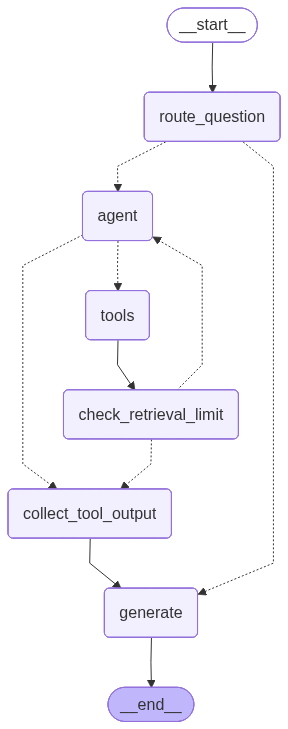

In [21]:
graph


### Code Explanation

This cell executes a retrieval-only path through the LangGraph agent. It simulates a scenario where the system relies solely on vector store retrieval to answer a domain-specific question, bypassing any complex reasoning or tool use that might be triggered by other query types.


In [22]:
# Case 1: vector store only — domain-specific question about the PDF
query_vs = "According to the report, how will the adoption of electric vehicles impact oil demand?"

# Invoke the graph using a specific set of inputs designed for pure retrieval.
# This tests the graph's ability to retrieve relevant documents based on the query without needing other tools or complex steps.
result_vs = graph.invoke({"query": query_vs, "messages": [], "retrieved_docs": [], "context": "", "retrieval_count": 0, "max_retrieval_steps": 5})


### Code Explanation

This cell prints the structured output of a retrieval-only run (Case 1). It verifies if the system determined that retrieval was necessary, how many documents were retrieved, provides a preview of the context used, and finally displays the generated answer based solely on the vector store's capabilities.


In [23]:
print("=== CASE 1: Vector Store Only ===")
print(f"needs_retrieval  : {result_vs['needs_retrieval']}")
print(f"retrieval_count  : {result_vs['retrieval_count']}")
print(f"retrieved_docs   : {len(result_vs.get('retrieved_docs') or [])} docs")
print(f"context preview  : {result_vs.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_vs['generation']}")

=== CASE 1: Vector Store Only ===
needs_retrieval  : True
retrieval_count  : 1
retrieved_docs   : 6 docs
context preview  : 

## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pi...

Generation:
Briefly, the report says EV adoption will reduce oil demand but not quickly or uniformly:

- EVs primarily displace gasoline demand from passenger cars; diesel (trucks, buses, equipment) is much harder to electrify.  
- By flattening or reversing road-transport demand growth, EVs raise the chance that global spare capacity stays above the 2–3 million barrels/day buffer, so the marginal (near‑term) effect on price dynamics can be important even if aggregate displacement is modest.  
- Full fleet turnover is slow (global stock ~1.4 billion vehicles; ~90 million new cars/year; typical lifetimes 15–20+ years), so substantial demand reduction is gradual and will be most pronounced after ~2035 and first in advanced economies.  
- There

### Code Explanation

This cell executes the LangGraph workflow using a web search query. Since the information is external (current temperature), the graph relies solely on its web retrieval tool, demonstrating how RAG can handle up-to-date, non-document-specific queries.


In [24]:
# Case 2: web search only — current information not in the PDF
query_web = "What is the current temperature in New Delhi?"

# Invoke the graph with a query that requires external knowledge (web search).
# We pass empty lists/strings for document-specific inputs, forcing the graph to use its web tool.
result_web = graph.invoke({"query": query_web, "messages": [], "retrieved_docs": [], "context": "", "retrieval_count": 0, "max_retrieval_steps": 5})


### Code Explanation

This cell prints a structured summary of the results obtained from the 'Web Search Only' case. It verifies if retrieval was deemed necessary, how many documents were retrieved, provides a preview of the context used for generation, and finally displays the generated answer.


In [25]:
print("=== CASE 2: Web Search Only ===")
print(f"needs_retrieval  : {result_web['needs_retrieval']}")
print(f"retrieval_count  : {result_web['retrieval_count']}")
print(f"retrieved_docs   : {len(result_web.get('retrieved_docs') or [])} docs")
print(f"context preview  : {result_web.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_web['generation']}")

=== CASE 2: Web Search Only ===
needs_retrieval  : True
retrieval_count  : 1
retrieved_docs   : 3 docs
context preview  : 

## Web Search Results

{'location': {'name': 'New Delhi', 'region': 'Delhi', 'country': 'India', 'lat': 28.6, 'lon': 7...

Generation:
The current temperature in New Delhi is 38.0°C (100.4°F).


### Code Explanation

This cell executes the LangGraph workflow (`graph.invoke`) for a complex query that requires synthesizing information from two sources: internal document retrieval (the EV report) and external, real-time web data (current oil demand due to geopolitical events). It simulates a multi-step reasoning process where both context types are necessary for a comprehensive answer.


In [26]:
# Case 3: both tools — requires document context AND current web data
query_both = "Compare what the EV report projects for 2030 oil demand with current oil demand due to Iran-US War."

# Invoke the graph, passing all necessary initial state variables (query, empty messages/context, etc.)
result_both = graph.invoke({"query": query_both, "messages": [], "retrieved_docs": [], "context": "", "retrieval_count": 0, "max_retrieval_steps": 5})


### Code Explanation

This cell prints the final results of the complex RAG process when both retrieval and tool-use capabilities are active. It systematically displays whether retrieval was needed, how many documents were retrieved, a preview of the context used for generation, and finally, the generated answer itself.


In [27]:
print("=== CASE 3: Both Tools ===")
print(f"needs_retrieval  : {result_both['needs_retrieval']}")
print(f"retrieval_count  : {result_both['retrieval_count']}")
print(f"retrieved_docs   : {len(result_both.get('retrieved_docs') or [])} docs")
print(f"context preview  : {result_both.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_both['generation']}")


=== CASE 3: Both Tools ===
needs_retrieval  : True
retrieval_count  : 1
retrieved_docs   : 10 docs
context preview  : 

## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pi...

Generation:
Short answer: the EV report excerpts provided do not give a specific numeric global oil‑demand projection for 2030. They describe a gradual, structural demand reduction from accelerating EV adoption that becomes economically material in the early 2030s and that can flatten or reverse demand growth (especially gasoline), increasing the chance that spare capacity stays above a 2–3 million barrels‑per‑day insurance threshold. By contrast, the Iran–US war effects described in the web snippets are an immediate near‑term shock: the IEA sees a small demand decline of about 80,000 bpd in 2026 and a much larger change versus pre‑war forecasts (the web result cites global demand being almost 1 million bpd less than forecast before the Iran war),

### Code Explanation

This cell executes a multi-round retrieval query designed to test the agent's ability to perform iterative, complex information gathering. The `graph.invoke` method runs the LangGraph workflow using a highly structured prompt (`query_multi`) that explicitly guides the agent through three distinct search steps (report projections $ightarrow$ web data $ightarrow$ gap filling), simulating real-world research workflows.


In [30]:
# Case 3b: multi-round retrieval — query designed to trigger iterative tool calls
# The agent is expected to: (1) search the vector store for report projections,
# then (2) search the web for current data, then (3) search again to fill any gaps.
query_multi = (
    "Step 1: Look up what the EV report projects for oil demand displacement by 2030 and 2050. "
    "Step 2: Search for the latest 2024-2025 EV sales data and battery cost trends. "
    "Step 3: Search for any recent analyst forecasts that revise those oil demand projections upward or downward. "
    "Synthesize all three into a coherent answer." 
)

# Invoke the LangGraph workflow with the complex query.
# The graph is initialized with necessary state variables (query, messages, etc.)
result_multi = graph.invoke({"query": query_multi, "messages": [], "retrieved_docs": [], "context": "", "retrieval_count": 0, "max_retrieval_steps": 5})


### Code Explanation

This cell prints the final results of a multi-round retrieval process. It systematically displays key metrics (like whether retrieval was needed, the number of retrievals, and the total documents retrieved) along with a preview of the context used for generation, followed by the final generated answer.


In [32]:
print("=== CASE 3b: Multi-Round Retrieval ===")
print(f"needs_retrieval  : {result_multi['needs_retrieval']}")
print(f"retrieval_count  : {result_multi['retrieval_count']}")
print(f"retrieved_docs   : {len(result_multi.get('retrieved_docs') or [])} docs")
print(f"context preview  : {result_multi.get('context', '')[:120]}...")
print(f"\nGeneration:\n{result_multi['generation']}")

=== CASE 3b: Multi-Round Retrieval ===
needs_retrieval  : True
retrieval_count  : 2
retrieved_docs   : 10 docs
context preview  : 

## Vector Store Results

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pi...

Generation:
Short answer up front
- The provided EV report excerpts do not give explicit numeric oil‑displacement projections for 2030 or 2050.  
- External material included in the context (IEA snippets in the web results) gives a mid‑single‑million barrels/day reduction by 2030 (roughly 5–6 mb/d) and larger reductions by the mid‑2030s (cited ~13 mb/d by 2035), but also an IEA framing that total oil demand may only be down ~8% by 2050 versus 2024.  
- The report emphasizes (qualitatively) that EVs will mainly displace gasoline (passenger cars), diesel is harder to electrify, fleet turnover takes decades, and outcomes depend heavily on emerging‑market vehicle growth and OPEC+ production policy.

Step 1 — What the EV report (Will EVs Da

### Case 4: No Retrieval (General Knowledge)

This cell demonstrates the graph's ability to answer questions that do not require external document retrieval. By explicitly passing empty lists/strings for `retrieved_docs`, `context`, and setting `retrieval_count` to 0, we force the RAG pipeline to rely solely on its internal knowledge base or LLM capabilities.


In [28]:
# Case 4: no retrieval — answerable from general knowledge
query_none = "Explain the difference between kinetic energy and potential energy."

# Invoke the graph, explicitly passing empty values for all retrieval-related inputs 
# to ensure the model answers based on its internal knowledge rather than documents.
result_none = graph.invoke({"query": query_none, "messages": [], "retrieved_docs": [], "context": "", "retrieval_count": 0, "max_retrieval_steps": 5})


### Case Analysis: No Retrieval Needed

This cell demonstrates the output when the system determines that no external retrieval is necessary. It prints key metrics (like `needs_retrieval`, `retrieval_count`, and document count) and displays the final generated response, confirming the model's ability to answer using only its internal knowledge.


In [29]:
print("=== CASE 4: No Retrieval ===")
print(f"needs_retrieval  : {result_none['needs_retrieval']}")
print(f"retrieval_count  : {result_none['retrieval_count']}")
print(f"retrieved_docs   : {len(result_none.get('retrieved_docs') or [])} docs")
print(f"context preview  : {result_none.get('context', '') or '(none)'}")
print(f"\nGeneration:\n{result_none['generation']}")

=== CASE 4: No Retrieval ===
needs_retrieval  : False
retrieval_count  : 0
retrieved_docs   : 0 docs
context preview  : (none)

Generation:
Kinetic energy and potential energy are two basic forms of mechanical energy. The main difference is that kinetic energy is energy of motion, while potential energy is stored energy due to an object's position or configuration.

Key points

- Kinetic energy (KE)
  - Definition: energy an object has because of its motion.
  - Formula (linear): KE = 1/2 · m · v^2, where m is mass and v is speed.
  - Also exists for rotation: KE_rot = 1/2 · I · ω^2 (I = moment of inertia, ω = angular speed).
  - Depends only on mass and speed; always nonnegative.
  - Example: a moving car, a flying baseball, or a spinning wheel.

- Potential energy (PE)
  - Definition: energy stored in an object because of its position in a force field or its configuration.
  - Common forms and formulas:
    - Gravitational near Earth: PE = m · g · h (h = height above chosen reference